# Tutorial 6: Mixed Precision Quantization Search with Mase and Optuna

In this tutorial, we'll see how Mase can be integrated with Optuna, the popular hyperparameter optimization framework, to search for a Bert model optimized for sequence classification on the IMDb dataset. We'll take the Optuna-generated model and import it into Mase, then run the CompressionPipeline to prepare the model for edge deployment by quantizing and pruning its weights.

As we'll see, running Architecture Search with Mase/Optuna involves the following steps.

1. **Define the search space**: this is a dictionary containing the range of values for each parameter at each layer in the model.

2. **Write the model constructor**: this is a function which uses Optuna utilities to sample a model from the search space, and constructs the model using transformers from_config class method.

3. **Write the objective function**: this function calls on the model constructor defined in Step 2 and defines the training/evaluation setup for each search iteration.

4. **Go!** Choose an Optuna sampler, create a study and launch the search.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can load the Bert checkpoint directly from HuggingFace.

In [2]:
from transformers import AutoModel

model = AutoModel.from_pretrained(checkpoint)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


If you have previously ran the tutorial on Neural Architecture Search (NAS), run the following cell to import the best model obtained from the search process.

In [3]:
from pathlib import Path
import dill

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "rb") as f:
    base_model = dill.load(f)

First, fetch the dataset using the `get_tokenized_dataset` utility.

In [4]:
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


## 1. Defining the Search Space

We'll start by defining a search space, i.e. enumerating the possible combinations of hyperparameters that Optuna can choose during search. We'll explore the following range of values for the model's hidden size, intermediate size, number of layers and number of heads.

In [ ]:
import torch
from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatDenorm,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    LinearBlockMinifloat,
    LinearBlockLog,
    LinearBinary,
    LinearBinaryScaling,
    LinearBinaryResidualSign,
)

search_space = {
    "linear_layer_choices": [
        torch.nn.Linear,
        LinearInteger,
    ],
}

## 2. Writing a Model Constructor

We define the following function, which will get called in each iteration of the search process. The function is passed the `trial` argument, which is an Optuna object that comes with many functionalities - see the [Trial documentation](https://optuna.readthedocs.io/en/stable/reference/trial.html) for more details. Here, we use the `trial.suggest_categorical` function, which triggers the chosen sampler to choose a layer type. The suggested integer is the index into the search space for each parameter, which we defined in the previous cell.

In [ ]:
from chop.tools.utils import deepsetattr
from copy import deepcopy


def construct_model(trial):

    # Fetch the model
    trial_model = deepcopy(base_model)

    # Quantize layers according to optuna suggestions
    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == torch.nn.Linear:
                continue

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
            }

            # If the chosen layer is integer, define the low precision config
            if new_layer_cls == LinearInteger:
                kwargs["config"] = {
                    "data_in_width": 8,
                    "data_in_frac_width": 4,
                    "weight_width": 8,
                    "weight_frac_width": 4,
                    "bias_width": 8,
                    "bias_frac_width": 4,
                }
            # elif... (other precisions)

            # Create the new layer (copy the weights)
            new_layer = new_layer_cls(**kwargs)
            new_layer.weight.data = layer.weight.data

            # Replace the layer in the model
            deepsetattr(trial_model, name, new_layer)

    return trial_model

## 3. Defining the Objective Function

Next, we define the objective function for the search, which gets called on each trial. In each trial, we create a new model instace with chosen hyperparameters according to the defined sampler. We then use the `get_trainer` utility in Mase to run a training loop on the IMDb dataset for a number of epochs. Finally, we use `evaluate` to report back the classification accuracy on the test split.

In [7]:
from chop.tools import get_trainer
import random


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

## 4. Launching the Search

Optuna provides a number of samplers, for example:

* **GridSampler**: iterates through every possible combination of hyperparameters in the search space
* **RandomSampler**: chooses a random combination of hyperparameters in each iteration
* **TPESampler**: uses Tree-structured Parzen Estimator algorithm to choose hyperparameter values.

You can define the chosen sampler by simply importing from `optuna.samplers` as below.

In [8]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = RandomSampler()

With all the pieces in place, we can launch the search as follows. The number of trials is set to 1 so you can go get a coffee for 10 minutes, then proceed with the tutorial. However, this will essentially be a random model - for better results, set this to 100 and leave it running overnight!

In [9]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=1,
    timeout=60 * 60 * 24,
)

[I 2026-01-30 12:52:40,560] A new study created in memory with name: bert-tiny-nas-study
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearInteger'> which is of type type.
  warnings.warn(message)
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.316900
1000,0.302600
1500,0.292500
2000,0.311000
2500,0.311600
3000,0.329600


[I 2026-01-30 12:57:59,728] Trial 0 finished with value: 0.87024 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.pooler.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'classifier_type': <class 'chop.nn.quant

# Task 1

In Tutorial 6, all layers allocated to IntegerLinear are allocated the same width and fractional width. This is suboptimal, as different layers may have different sensitivities to quantization.

a. Modify the code to allow different layers to have widths in the range [8, 16, 32] and fractional widths in the range [2, 4, 8]. Expose this choice as an additional hyperparameter for the Optuna sampler.

b. Run the search again, and plot a figure that has the number of trials on the x axis, and the maximum achieved accuracy up to that point on the y axis.

In [2]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from transformers import AutoModel

model = AutoModel.from_pretrained(checkpoint)

from pathlib import Path
import dill

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "rb") as f:
    base_model = dill.load(f)

from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


In [3]:
import torch
from copy import deepcopy
from chop.tools.utils import deepsetattr
from chop.nn.quantized.modules.linear import LinearInteger

# --- Search space ---
search_space = {
    "linear_layer_choices": [
        torch.nn.Linear,
        LinearInteger,
    ],
    "width_choices": [8, 16, 32],
    "frac_width_choices": [2, 4, 8],
}

def construct_model(trial):
    # Fetch the model
    trial_model = deepcopy(base_model)

    # Quantize layers according to optuna suggestions
    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            # Keep FP32 layer
            if new_layer_cls == torch.nn.Linear:
                continue

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
            }

            # If the chosen layer is integer, define low precision config
            if new_layer_cls == LinearInteger:
                # --- NEW: expose width/frac choices as Optuna hyperparameters ---
                data_in_width = trial.suggest_categorical(
                    f"{name}_data_in_width",
                    search_space["width_choices"],
                )
                data_in_frac_width = trial.suggest_categorical(
                    f"{name}_data_in_frac_width",
                    search_space["frac_width_choices"],
                )

                weight_width = trial.suggest_categorical(
                    f"{name}_weight_width",
                    search_space["width_choices"],
                )
                weight_frac_width = trial.suggest_categorical(
                    f"{name}_weight_frac_width",
                    search_space["frac_width_choices"],
                )

                bias_width = trial.suggest_categorical(
                    f"{name}_bias_width",
                    search_space["width_choices"],
                )
                bias_frac_width = trial.suggest_categorical(
                    f"{name}_bias_frac_width",
                    search_space["frac_width_choices"],
                )

                kwargs["config"] = {
                    "data_in_width": data_in_width,
                    "data_in_frac_width": data_in_frac_width,
                    "weight_width": weight_width,
                    "weight_frac_width": weight_frac_width,
                    "bias_width": bias_width,
                    "bias_frac_width": bias_frac_width,
                }

            # elif ... other quantized types
            else:
                raise NotImplementedError(f"Unsupported layer class: {new_layer_cls}")

            # Create the new layer (copy weights & bias)
            new_layer = new_layer_cls(**kwargs)
            with torch.no_grad():
                new_layer.weight.copy_(layer.weight)
                if getattr(layer, "bias", None) is not None and getattr(new_layer, "bias", None) is not None:
                    new_layer.bias.copy_(layer.bias)

            # Replace the layer in the model
            deepsetattr(trial_model, name, new_layer)

    return trial_model


from chop.tools import get_trainer
import optuna

# Global log (lives only in this Python session)
TRIAL_LOG = []  # list of dicts

def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Save to global variable
    acc = float(eval_results["eval_accuracy"])
    TRIAL_LOG.append({"trial": trial.number, "accuracy": acc})

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]


In [4]:
from optuna.samplers import RandomSampler

sampler = RandomSampler()

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=30,
    timeout=60 * 60 * 24,
)

import json

with open("tut_6_nas_width_trial_log.json", "w") as f:
    json.dump(TRIAL_LOG, f, indent=2)

print("Saved trial log to tut_6_nas_width_trial_log.json")

from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open(f"{Path.home()}/tut_6_nas_width_trial_log.pkl", "wb") as f:
    dill.dump(model, f)

[I 2026-02-01 16:41:01,445] A new study created in memory with name: bert-tiny-nas-study
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearInteger'> which is of type type.
  warnings.warn(message)
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.691600
2500,0.663100
3000,0.637700


[I 2026-02-01 16:46:00,869] Trial 0 finished with value: 0.82444 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_data_in_width': 16, 'bert.encoder.layer.0.attention.self.query_data_in_frac_width': 8, 'bert.encoder.layer.0.attention.self.query_weight_width': 16, 'bert.encoder.layer.0.attention.self.query_weight_frac_width': 2, 'bert.encoder.layer.0.attention.self.query_bias_width': 32, 'bert.encoder.layer.0.attention.self.query_bias_frac_width': 4, 'bert.encoder.layer.0.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.output.dense_data_in_width': 32, 'bert.encoder.layer.0.output.dense_data_in_frac_width': 2, 'bert.encoder.layer.0.output.dense

Step,Training Loss
500,0.361400
1000,0.323400
1500,0.322000
2000,0.326000
2500,0.338100
3000,0.358800


[I 2026-02-01 16:51:07,414] Trial 1 finished with value: 0.8738 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_data_in_width': 8, 'bert.encoder.layer.0.attention.self.query_data_in_frac_width': 8, 'bert.encoder.layer.0.attention.self.query_weight_width': 32, 'bert.encoder.layer.0.attention.self.query_weight_frac_width': 2, 'bert.encoder.layer.0.attention.self.query_bias_width': 32, 'bert.encoder.layer.0.attention.self.query_bias_frac_width': 2, 'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.key_data_in_width': 32, 'bert.encoder.layer.0.attention.self.key_data_in_frac_width': 4, 'bert.encoder.layer.0.attention.self.key_weight_width': 8, 'bert.encoder.layer.0.attention.self.key_weight_frac_width': 4, 'bert.encoder.layer.0.attention.self.key_bias_width': 8, 'bert.encoder.laye

...

Step,Training Loss
500,0.693100
1000,0.693100
1500,0.669200
2000,0.622900
2500,0.569700
3000,0.556400


[I 2026-02-01 19:03:34,981] Trial 28 finished with value: 0.86448 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_data_in_width': 32, 'bert.encoder.layer.0.attention.self.query_data_in_frac_width': 4, 'bert.encoder.layer.0.attention.self.query_weight_width': 8, 'bert.encoder.layer.0.attention.self.query_weight_frac_width': 8, 'bert.encoder.layer.0.attention.self.query_bias_width': 32, 'bert.encoder.layer.0.attention.self.query_bias_frac_width': 4, 'bert.encoder.layer.0.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.intermediate.dense_data_in_width': 8, 'bert.encoder.layer.0.intermediate.dense_data_in_frac_width': 2, 'bert.encoder.layer.0.intermediate.dense_weight_width': 16, 'bert.encoder.layer.0.intermediate.dense_weight

Step,Training Loss
500,0.301100
1000,0.300400
1500,0.298400
2000,0.312900
2500,0.312300
3000,0.341300


[I 2026-02-01 19:08:26,502] Trial 29 finished with value: 0.87068 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_data_in_width': 16, 'bert.encoder.layer.0.attention.self.query_data_in_frac_width': 8, 'bert.encoder.layer.0.attention.self.query_weight_width': 16, 'bert.encoder.layer.0.attention.self.query_weight_frac_width': 8, 'bert.encoder.layer.0.attention.self.query_bias_width': 32, 'bert.encoder.layer.0.attention.self.query_bias_frac_width': 2, 'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.key_data_in_width': 32, 'bert.encoder.layer.0.attention.self.key_data_in_frac_width': 4, 'bert.encoder.layer.0.attention.self.key_weight_width': 8, 'bert.encoder.layer.0.attention.self.key_weight_frac_width': 8, 'bert.encoder.layer.0.attention.self.key_bias_width': 32, 'bert.encoder.

Saved trial log to tut_6_nas_width_trial_log.json


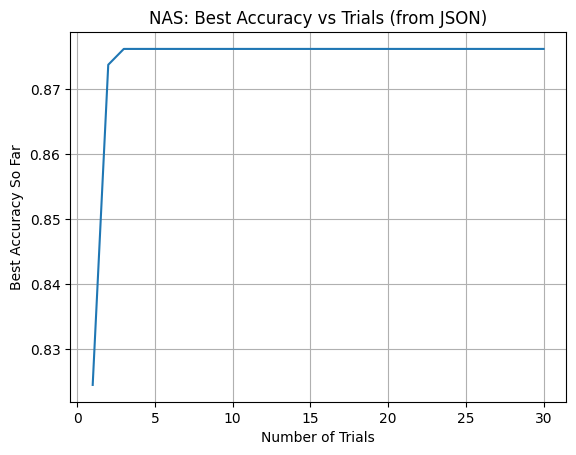

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load trial log
with open("tut_6_nas_width_trial_log.json") as f:
    trial_log = json.load(f)

# Sort by trial number (important)
trial_log = sorted(trial_log, key=lambda x: x["trial"])

# Extract accuracies
accuracies = [entry["accuracy"] for entry in trial_log]

# Compute best-so-far curve
best_so_far = np.maximum.accumulate(accuracies)

# X axis: number of trials
x = np.arange(1, len(best_so_far) + 1)

# Plot
plt.figure()
plt.plot(x, best_so_far)
plt.xlabel("Number of Trials")
plt.ylabel("Best Accuracy So Far")
plt.title("NAS: Best Accuracy vs Trials (from JSON)")
plt.grid(True)
plt.show()

# Task 2

In Section 1 of Tutorial 6, when defining the search space, a number of layers are imported, however only LinearInteger and the full precision nn.Linear are selected.

a. Now, extend the search to consider all supported precisions for the Linear layer in Mase, including Minifloat, BlockFP, BlockLog, Binary, etc. This may also require changing the model constructor so the required arguments are passed when instantiating each layer.

b. Run the search again, and plot a figure that has the number of trials on the x axis, and the maximum achieved accuracy up to that point on the y axis. Plot one curve for each precision to compare their performance.

In [5]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from transformers import AutoModel

model = AutoModel.from_pretrained(checkpoint)

from pathlib import Path
import dill

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "rb") as f:
    base_model = dill.load(f)

from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


In [ ]:
import json
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import optuna
import torch

from chop.tools.utils import deepsetattr
from chop.tools import get_trainer

from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatDenorm,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    LinearBlockMinifloat,
    LinearBlockLog,
    LinearBinary,
    LinearBinaryScaling,
    LinearBinaryResidualSign,
)

# -----------------------------
# Precision families (Task 2a)
# -----------------------------
PRECISION_CLASSES = {
    "fp32": torch.nn.Linear,
    "integer": LinearInteger,
    "minifloat_ieee": LinearMinifloatIEEE,
    "minifloat_denorm": LinearMinifloatDenorm,
    "log": LinearLog,
    "block_fp": LinearBlockFP,
    "block_minifloat": LinearBlockMinifloat,
    "block_log": LinearBlockLog,
    "binary": LinearBinary,
    "binary_scaling": LinearBinaryScaling,
    "binary_residual_sign": LinearBinaryResidualSign,
}

# Search space knobs (you can widen these later)
SEARCH_SPACE = {
    # shared "bit-width-ish" knobs
    "width_choices": [8, 16, 32],
    "frac_width_choices": [2, 4, 8],

    # minifloat knobs
    "exp_width_choices": [2, 3, 4, 5, 8],
    "exp_bias_choices": [3, 7, 15, 31],

    # block/microscaling knobs
    "block_size_choices": [8, 16, 32, 64],  # common block granularities
    "block_exp_width_choices": [2, 3, 4, 5, 8],
    "block_exp_bias_choices": [3, 7, 15, 31],

    # binary knobs
    "binary_width_choices": [1],            # binary is typically 1-bit
    "binary_stochastic_choices": [False, True],
    "binary_bipolar_choices": [False, True],

    # optional knobs sometimes used by log/minifloat (leave if unsupported)
    "rounding_mode_choices": ["nearest", "stochastic"],
}


def suggest_linear_config(trial: optuna.Trial, name: str, layer_cls):
    """
    Return kwargs["config"] for the selected MASE quantized linear class.

    If your local chop version uses different config key names, adjust them here.
    """
    # FP32 Linear: no config needed
    if layer_cls == torch.nn.Linear:
        return None

    # -----------------------------
    # Integer (Tutorial 6 baseline)
    # -----------------------------
    if layer_cls == LinearInteger:
        cfg = {
            "data_in_width": trial.suggest_categorical(f"{name}_data_in_width", SEARCH_SPACE["width_choices"]),
            "data_in_frac_width": trial.suggest_categorical(f"{name}_data_in_frac_width", SEARCH_SPACE["frac_width_choices"]),
            "weight_width": trial.suggest_categorical(f"{name}_weight_width", SEARCH_SPACE["width_choices"]),
            "weight_frac_width": trial.suggest_categorical(f"{name}_weight_frac_width", SEARCH_SPACE["frac_width_choices"]),
            "bias_width": trial.suggest_categorical(f"{name}_bias_width", SEARCH_SPACE["width_choices"]),
            "bias_frac_width": trial.suggest_categorical(f"{name}_bias_frac_width", SEARCH_SPACE["frac_width_choices"]),
        }
        return cfg

    # -----------------------------
    # Minifloat (IEEE / Denorm)
    # Typical knobs: total width + exponent width (+ bias)
    # -----------------------------
    if layer_cls in (LinearMinifloatIEEE, LinearMinifloatDenorm):
        cfg = {
            "data_in_width": trial.suggest_categorical(f"{name}_data_in_width", SEARCH_SPACE["width_choices"]),
            "data_in_exponent_width": trial.suggest_categorical(f"{name}_data_in_exp_width", SEARCH_SPACE["exp_width_choices"]),
            "data_in_exponent_bias": trial.suggest_categorical(f"{name}_data_in_exp_bias", SEARCH_SPACE["exp_bias_choices"]),

            "weight_width": trial.suggest_categorical(f"{name}_weight_width", SEARCH_SPACE["width_choices"]),
            "weight_exponent_width": trial.suggest_categorical(f"{name}_weight_exp_width", SEARCH_SPACE["exp_width_choices"]),
            "weight_exponent_bias": trial.suggest_categorical(f"{name}_weight_exp_bias", SEARCH_SPACE["exp_bias_choices"]),

            "bias_width": trial.suggest_categorical(f"{name}_bias_width", SEARCH_SPACE["width_choices"]),
            "bias_exponent_width": trial.suggest_categorical(f"{name}_bias_exp_width", SEARCH_SPACE["exp_width_choices"]),
            "bias_exponent_bias": trial.suggest_categorical(f"{name}_bias_exp_bias", SEARCH_SPACE["exp_bias_choices"]),
        }

        # If your chop build supports rounding mode for minifloat, keep this;
        # otherwise delete these keys.
        cfg["rounding_mode"] = trial.suggest_categorical(f"{name}_rounding_mode", SEARCH_SPACE["rounding_mode_choices"])
        return cfg

    # -----------------------------
    # Log
    # Typical knobs: width + exponent width/bias (log domain encoding)
    # -----------------------------
    if layer_cls == LinearLog:
        cfg = {
            "data_in_width": trial.suggest_categorical(f"{name}_data_in_width", SEARCH_SPACE["width_choices"]),
            "data_in_exponent_width": trial.suggest_categorical(f"{name}_data_in_exp_width", SEARCH_SPACE["exp_width_choices"]),
            "data_in_exponent_bias": trial.suggest_categorical(f"{name}_data_in_exp_bias", SEARCH_SPACE["exp_bias_choices"]),

            "weight_width": trial.suggest_categorical(f"{name}_weight_width", SEARCH_SPACE["width_choices"]),
            "weight_exponent_width": trial.suggest_categorical(f"{name}_weight_exp_width", SEARCH_SPACE["exp_width_choices"]),
            "weight_exponent_bias": trial.suggest_categorical(f"{name}_weight_exp_bias", SEARCH_SPACE["exp_bias_choices"]),
        }
        return cfg

    # -----------------------------
    # Block formats (microscaling)
    # Typical knobs: element width + shared exponent per block
    # -----------------------------
    if layer_cls in (LinearBlockFP, LinearBlockMinifloat, LinearBlockLog):
        cfg = {
            "block_size": trial.suggest_categorical(f"{name}_block_size", SEARCH_SPACE["block_size_choices"]),

            # element-ish width
            "data_in_width": trial.suggest_categorical(f"{name}_data_in_width", SEARCH_SPACE["width_choices"]),
            "weight_width": trial.suggest_categorical(f"{name}_weight_width", SEARCH_SPACE["width_choices"]),

            # shared exponent per block
            "block_exponent_width": trial.suggest_categorical(f"{name}_block_exp_width", SEARCH_SPACE["block_exp_width_choices"]),
            "block_exponent_bias": trial.suggest_categorical(f"{name}_block_exp_bias", SEARCH_SPACE["block_exp_bias_choices"]),
        }
        return cfg

    # -----------------------------
    # Binary formats
    # -----------------------------
    if layer_cls in (LinearBinary, LinearBinaryScaling, LinearBinaryResidualSign):
        cfg = {
            "data_in_width": 8,  # keep activations reasonable; you can also search this
            "weight_width": 1,
            "stochastic": trial.suggest_categorical(f"{name}_stochastic", SEARCH_SPACE["binary_stochastic_choices"]),
            "bipolar": trial.suggest_categorical(f"{name}_bipolar", SEARCH_SPACE["binary_bipolar_choices"]),
        }

        # Scaling / residual-sign often add extra behavior; keep placeholders here.
        if layer_cls == LinearBinaryScaling:
            cfg["scaling"] = True
        if layer_cls == LinearBinaryResidualSign:
            cfg["residual_sign"] = True

        return cfg

    raise NotImplementedError(f"Unsupported layer class: {layer_cls}")


def construct_model_for_precision(trial: optuna.Trial, base_model, precision_name: str):
    """
    Replace every nn.Linear in base_model with the chosen precision class.
    This makes each Optuna study correspond to exactly one precision family.
    """
    layer_cls = PRECISION_CLASSES[precision_name]
    trial_model = deepcopy(base_model)

    for name, layer in trial_model.named_modules():
        if not isinstance(layer, torch.nn.Linear):
            continue

        # Keep FP32: no replacement
        if layer_cls == torch.nn.Linear:
            continue

        kwargs = {
            "in_features": layer.in_features,
            "out_features": layer.out_features,
        }

        cfg = suggest_linear_config(trial, name, layer_cls)
        if cfg is not None:
            kwargs["config"] = cfg

        new_layer = layer_cls(**kwargs)

        # copy parameters
        with torch.no_grad():
            new_layer.weight.copy_(layer.weight)
            if getattr(layer, "bias", None) is not None and getattr(new_layer, "bias", None) is not None:
                new_layer.bias.copy_(layer.bias)

        deepsetattr(trial_model, name, new_layer)

    return trial_model


In [ ]:
from optuna.samplers import RandomSampler

def run_precision_study(
    precision_name: str,
    base_model,
    dataset,
    tokenizer,
    n_trials: int = 30,
    num_train_epochs: int = 1,
):
    trial_accs = []

    def objective(trial: optuna.Trial):
        model = construct_model_for_precision(trial, base_model, precision_name)

        trainer = get_trainer(
            model=model,
            tokenized_dataset=dataset,
            tokenizer=tokenizer,
            evaluate_metric="accuracy",
            num_train_epochs=num_train_epochs,
        )

        trainer.train()
        eval_results = trainer.evaluate()
        acc = float(eval_results["eval_accuracy"])

        trial_accs.append(acc)
        return acc

    study = optuna.create_study(
        direction="maximize",
        study_name=f"tut6_precision_{precision_name}",
        sampler=RandomSampler(),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=60 * 60 * 24,
    )

    return study, trial_accs


# -----------------------------
# Run all precisions (Task 2b)
# -----------------------------
PRECISIONS_TO_RUN = [
    "fp32",
    "integer",
    "minifloat_ieee",
    "minifloat_denorm",
    "log",
    "block_fp",
    "block_minifloat",
    "block_log",
    "binary",
    "binary_scaling",
    "binary_residual_sign",
]

results_by_precision = {}
best_models = {}

for p in PRECISIONS_TO_RUN:
    study, accs = run_precision_study(
        precision_name=p,
        base_model=base_model,
        dataset=dataset,
        tokenizer=tokenizer,
        n_trials=30,
        num_train_epochs=1,
    )
    results_by_precision[p] = accs
    # best trial model can be reconstructed later from best params;
    # storing full model objects inside trial attrs is usually heavy.
    best_models[p] = {
        "best_value": float(study.best_value),
        "best_params": study.best_params,
    }

# -----------------------------
# Save logs
# -----------------------------
with open("tut6_task2_results_by_precision.json", "w") as f:
    json.dump(results_by_precision, f, indent=2)

with open("tut6_task2_best_params.json", "w") as f:
    json.dump(best_models, f, indent=2)

print("Saved:")
print(" - tut6_task2_results_by_precision.json")
print(" - tut6_task2_best_params.json")


# -----------------------------
# Plot: trial vs max accuracy so far
# -----------------------------
plt.figure()
for p, accs in results_by_precision.items():
    if len(accs) == 0:
        continue
    best_so_far = []
    m = None
    for a in accs:
        m = a if (m is None or a > m) else m
        best_so_far.append(m)

    xs = list(range(1, len(best_so_far) + 1))
    plt.plot(xs, best_so_far, label=p)

plt.xlabel("Number of trials")
plt.ylabel("Max accuracy up to this trial")
plt.title("Tutorial 6 Task 2: Best-so-far accuracy vs trials (by precision)")
plt.legend()
plt.tight_layout()
plt.savefig("tut6_task2_precision_comparison.png", dpi=200)
print("Saved plot: tut6_task2_precision_comparison.png")
